 # Step 2 — Data Collection and Understanding



 **Capstone:** AI-Powered Household Energy Consumption Prediction

 and Monitoring System



 This notebook:



 1. Downloads the UCI Individual Household Electric Power Consumption dataset.

 2. Loads and validates the raw data.

 3. Examines feature types, missing values, duplicates, timestamp gaps,

    distributions, and potential outliers.

 4. Produces a complete data dictionary.

 5. Documents dataset limitations and suitability for the capstone.



 **Primary future target:** Next-day total household electricity

 consumption in kilowatt-hours (kWh).

In [1]:
from pathlib import Path
from zipfile import ZipFile
import platform
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns

from IPython.display import display

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Display configuration
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

sns.set_theme(style="whitegrid", context="notebook")

print(f"Python: {sys.version.split()[0]}")
print(f"Platform: {platform.platform()}")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")


Python: 3.11.16
Platform: Windows-10-10.0.26200-SP0
Pandas: 2.3.3
NumPy: 2.4.6


 ## 1. Project paths



 The following code works whether this file is executed from the repository

 root or from inside the `notebooks` directory.

In [2]:
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

for directory in [RAW_DIR, PROCESSED_DIR, TABLES_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

ZIP_PATH = RAW_DIR / "household_power_consumption.zip"
DATA_PATH = RAW_DIR / "household_power_consumption.txt"

print(f"Project root: {PROJECT_ROOT.resolve()}")
print(f"Raw data directory: {RAW_DIR.resolve()}")


Project root: E:\My_Projects\AIM\capstone
Raw data directory: E:\My_Projects\AIM\capstone\data\raw


 ## 2. Dataset source



 **Dataset:** Individual Household Electric Power Consumption



 **Repository:** UCI Machine Learning Repository



 **Creators:** Georges Hebrail and Alice Berard



 **DOI:** https://doi.org/10.24432/C58K54



 **Official page:**

 https://archive.ics.uci.edu/dataset/235/individual+household+electric+power+consumption



 **License:** Creative Commons Attribution 4.0 International



 The dataset contains minute-level electricity measurements from one

 household in Sceaux, France. Measurements were collected from December 2006

 to November 2010.



 ### Suitability



 The dataset is suitable because it contains chronological household-level

 electricity measurements that can be aggregated into daily kWh and used for

 next-day consumption forecasting.



 ### Important limitation



 This dataset represents one household in France. Its consumption patterns,

 climate, appliances, voltage conditions, tariff structure, and household

 behaviour do not necessarily represent households in the Philippines or

 Meralco customers. It will be used to develop and evaluate the forecasting

 methodology, not to claim population-wide performance in the Philippines.

 ## 3. Download the dataset



 The download is skipped if the ZIP file already exists.

In [3]:
DATA_URL = (
    "https://archive.ics.uci.edu/static/public/235/"
    "individual+household+electric+power+consumption.zip"
)


def download_file(url: str, destination: Path) -> None:
    """Download a file in chunks to avoid loading it entirely into memory."""

    if destination.exists():
        print(f"Download skipped; file already exists: {destination}")
        return

    print(f"Downloading from:\n{url}")

    with requests.get(url, stream=True, timeout=180) as response:
        response.raise_for_status()

        with destination.open("wb") as output_file:
            for chunk in response.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    output_file.write(chunk)

    print(f"Download completed: {destination}")


download_file(DATA_URL, ZIP_PATH)

print(f"ZIP size: {ZIP_PATH.stat().st_size / (1024 ** 2):,.2f} MB")


Download skipped; file already exists: e:\My_Projects\AIM\capstone\data\raw\household_power_consumption.zip
ZIP size: 19.68 MB


 ## 4. Extract the raw text file

In [4]:
if DATA_PATH.exists():
    print(f"Extraction skipped; dataset already exists: {DATA_PATH}")
else:
    print("Extracting dataset...")

    with ZipFile(ZIP_PATH, "r") as archive:
        archive.extractall(RAW_DIR)

    print(f"Extraction completed: {DATA_PATH}")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Expected data file was not found after extraction: {DATA_PATH}"
    )

print(f"Extracted size: {DATA_PATH.stat().st_size / (1024 ** 2):,.2f} MB")


Extraction skipped; dataset already exists: e:\My_Projects\AIM\capstone\data\raw\household_power_consumption.txt
Extracted size: 124.82 MB


 ## 5. Load the raw dataset



 Important loading rules:



 - Fields are separated by semicolons.

 - Missing measurements are represented by `?`.

 - `Date` and `Time` are initially retained as text.

 - `low_memory=False` prevents inconsistent chunk-based type inference.

In [5]:
df_raw = pd.read_csv(
    DATA_PATH,
    sep=";",
    na_values=["?", ""],
    low_memory=False
)

print(f"Rows: {df_raw.shape[0]:,}")
print(f"Columns: {df_raw.shape[1]}")
display(df_raw.head())


Rows: 2,075,259
Columns: 9


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.2160,0.4180,234.8400,18.4000,0.0000,1.0000,17.0000
1,16/12/2006,17:25:00,5.3600,0.4360,233.6300,23.0000,0.0000,1.0000,16.0000
2,16/12/2006,17:26:00,5.3740,0.4980,233.2900,23.0000,0.0000,2.0000,17.0000
3,16/12/2006,17:27:00,5.3880,0.5020,233.7400,23.0000,0.0000,1.0000,17.0000
4,16/12/2006,17:28:00,3.6660,0.5280,235.6800,15.8000,0.0000,1.0000,17.0000


 ## 6. Validate the dataset structure



 These checks cause the notebook to stop if an unexpected file is loaded.

In [6]:
EXPECTED_COLUMNS = [
    "Date",
    "Time",
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",
]

missing_columns = sorted(set(EXPECTED_COLUMNS) - set(df_raw.columns))
unexpected_columns = sorted(set(df_raw.columns) - set(EXPECTED_COLUMNS))

assert not missing_columns, f"Required columns are missing: {missing_columns}"
assert not unexpected_columns, (
    f"Unexpected columns were found: {unexpected_columns}"
)
assert len(df_raw) > 0, "The dataset contains no records."

print("Dataset structure validation passed.")


Dataset structure validation passed.


 ## 7. Create and validate the timestamp

In [7]:
df = df_raw.copy()

df["datetime"] = pd.to_datetime(
    df["Date"].astype(str) + " " + df["Time"].astype(str),
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce"
)

invalid_timestamps = int(df["datetime"].isna().sum())

print(f"Invalid timestamps: {invalid_timestamps:,}")

assert invalid_timestamps == 0, (
    "Invalid timestamps were detected. Inspect Date and Time before proceeding."
)

df = (
    df.drop(columns=["Date", "Time"])
      .set_index("datetime")
      .sort_index()
)

print(f"Start: {df.index.min()}")
print(f"End:   {df.index.max()}")
print(f"Duration: {df.index.max() - df.index.min()}")

display(df.head())


Invalid timestamps: 0
Start: 2006-12-16 17:24:00
End:   2010-11-26 21:02:00
Duration: 1441 days 03:38:00


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.2160,0.4180,234.8400,18.4000,0.0000,1.0000,17.0000
2006-12-16 17:25:00,5.3600,0.4360,233.6300,23.0000,0.0000,1.0000,16.0000
2006-12-16 17:26:00,5.3740,0.4980,233.2900,23.0000,0.0000,2.0000,17.0000
2006-12-16 17:27:00,5.3880,0.5020,233.7400,23.0000,0.0000,1.0000,17.0000
2006-12-16 17:28:00,3.6660,0.5280,235.6800,15.8000,0.0000,1.0000,17.0000


 ## 8. Data types and feature classification

In [8]:
numeric_columns = list(df.columns)

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

type_summary = pd.DataFrame(
    {
        "variable": df.columns,
        "pandas_dtype": [str(df[column].dtype) for column in df.columns],
        "feature_type": "Continuous numeric",
        "role": "Predictor / measurement",
    }
)

display(type_summary)

print("\nDataFrame information:")
df.info()


,variable,pandas_dtype,feature_type,role
0,Global_active_power,float64,Continuous numeric,Predictor / measurement
1,Global_reactive_power,float64,Continuous numeric,Predictor / measurement
2,Voltage,float64,Continuous numeric,Predictor / measurement
3,Global_intensity,float64,Continuous numeric,Predictor / measurement
4,Sub_metering_1,float64,Continuous numeric,Predictor / measurement
5,Sub_metering_2,float64,Continuous numeric,Predictor / measurement
6,Sub_metering_3,float64,Continuous numeric,Predictor / measurement



DataFrame information:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2075259 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 7 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float64
 1   Global_reactive_power  float64
 2   Voltage                float64
 3   Global_intensity       float64
 4   Sub_metering_1         float64
 5   Sub_metering_2         float64
 6   Sub_metering_3         float64
dtypes: float64(7)
memory usage: 126.7 MB


 ## 9. Missing-value assessment



 Missing measurements are retained during Step 2 so their frequency and

 temporal pattern can be studied. Imputation decisions belong to Step 3.

In [9]:
missing_summary = (
    pd.DataFrame(
        {
            "missing_count": df.isna().sum(),
            "missing_percent": df.isna().mean().mul(100),
            "non_missing_count": df.notna().sum(),
        }
    )
    .sort_values("missing_percent", ascending=False)
)

missing_summary.index.name = "variable"

display(missing_summary)

rows_with_missing = int(df.isna().any(axis=1).sum())
rows_with_missing_percent = rows_with_missing / len(df) * 100

print(f"Rows containing at least one missing value: {rows_with_missing:,}")
print(f"Percentage of rows with missing data: {rows_with_missing_percent:.4f}%")

missing_summary.to_csv(TABLES_DIR / "missing_value_summary.csv")


,missing_count,missing_percent,non_missing_count
variable,,,
Global_active_power,25979,1.2518,2049280
Global_reactive_power,25979,1.2518,2049280
Voltage,25979,1.2518,2049280
Global_intensity,25979,1.2518,2049280
Sub_metering_1,25979,1.2518,2049280
Sub_metering_2,25979,1.2518,2049280
Sub_metering_3,25979,1.2518,2049280


Rows containing at least one missing value: 25,979
Percentage of rows with missing data: 1.2518%


 ### Missing values over time



 Monthly missing-value counts help determine whether missing observations are

 isolated or concentrated in particular periods.

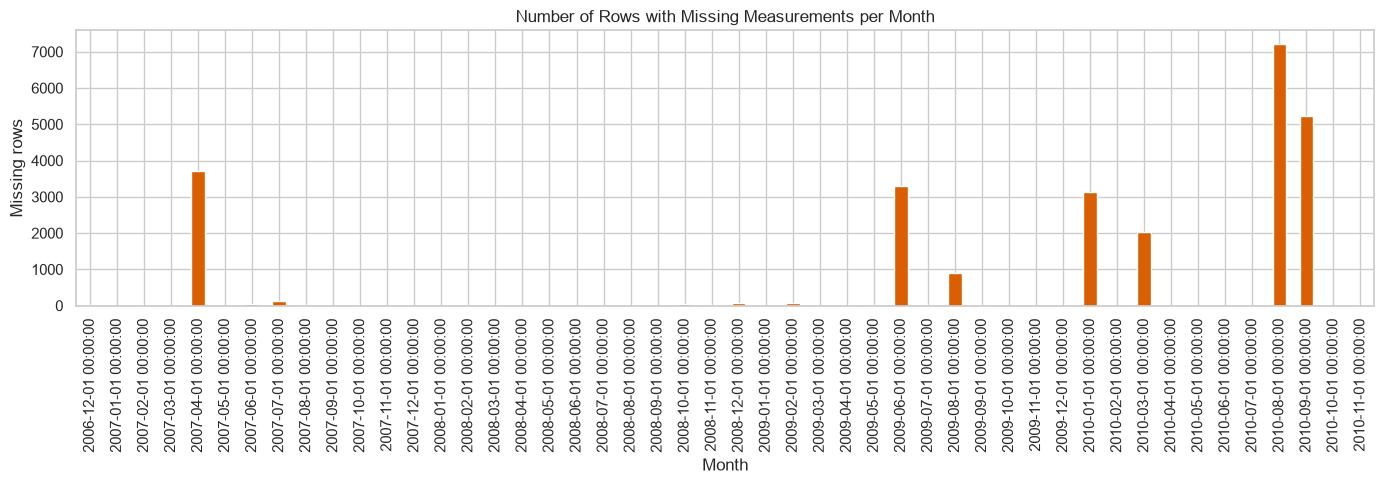

In [10]:
monthly_missing = (
    df.isna()
      .any(axis=1)
      .astype(int)
      .resample("MS")
      .sum()
)

fig, ax = plt.subplots(figsize=(14, 5))

monthly_missing.plot(
    kind="bar",
    ax=ax,
    color="#d95f02"
)

ax.set_title("Number of Rows with Missing Measurements per Month")
ax.set_xlabel("Month")
ax.set_ylabel("Missing rows")
ax.tick_params(axis="x", labelrotation=90)

plt.tight_layout()
plt.show()


 ## 10. Duplicate and timestamp assessment



 Two kinds of duplicates are evaluated:



 1. Repeated timestamps

 2. Completely duplicated measurement rows



 Repeated measurements are not removed during Step 2.

In [11]:
duplicate_timestamps = int(df.index.duplicated(keep=False).sum())
duplicate_measurement_rows = int(df.duplicated(keep=False).sum())

duplicate_summary = pd.DataFrame(
    {
        "check": [
            "Rows with duplicated timestamps",
            "Completely duplicated measurement rows",
        ],
        "count": [
            duplicate_timestamps,
            duplicate_measurement_rows,
        ],
    }
)

display(duplicate_summary)

if duplicate_timestamps > 0:
    display(df[df.index.duplicated(keep=False)].head(20))


,check,count
0,Rows with duplicated timestamps,0
1,Completely duplicated measurement rows,247619


 ## 11. Timestamp continuity



 The expected interval between records is one minute. Timestamp gaps and

 missing measurement values are different:



 - A timestamp gap means the timestamp itself is absent.

 - A missing measurement means the timestamp exists, but one or more

   measurements are unavailable.

In [12]:
timestamp_differences = df.index.to_series().diff()

gap_summary = timestamp_differences.value_counts().sort_index().head(10)

print("Most common intervals between consecutive timestamps:")
display(gap_summary)

non_one_minute_gaps = timestamp_differences[
    timestamp_differences > pd.Timedelta(minutes=1)
]

print(f"Intervals longer than one minute: {len(non_one_minute_gaps):,}")

if len(non_one_minute_gaps) > 0:
    display(non_one_minute_gaps.head(20))

expected_index = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq="min"
)

missing_timestamps = expected_index.difference(df.index)

print(f"Expected timestamps: {len(expected_index):,}")
print(f"Observed timestamps: {len(df.index):,}")
print(f"Absent timestamps: {len(missing_timestamps):,}")


Most common intervals between consecutive timestamps:


datetime
0 days 00:01:00    2075258
Name: count, dtype: int64

Intervals longer than one minute: 0
Expected timestamps: 2,075,259
Observed timestamps: 2,075,259
Absent timestamps: 0


 ## 12. Descriptive statistics



 The table provides count, mean, standard deviation, minimum, quartiles,

 and maximum for each numerical measurement.

In [13]:
descriptive_statistics = df.describe().T

descriptive_statistics["missing_count"] = df.isna().sum()
descriptive_statistics["missing_percent"] = df.isna().mean().mul(100)

display(descriptive_statistics)

descriptive_statistics.to_csv(
    TABLES_DIR / "descriptive_statistics.csv"
)


,count,mean,std,min,25%,50%,75%,max,missing_count,missing_percent
Global_active_power,"2,049,280.0000",1.0916,1.0573,0.0760,0.3080,0.6020,1.5280,11.1220,25979,1.2518
Global_reactive_power,"2,049,280.0000",0.1237,0.1127,0.0000,0.0480,0.1000,0.1940,1.3900,25979,1.2518
Voltage,"2,049,280.0000",240.8399,3.2400,223.2000,238.9900,241.0100,242.8900,254.1500,25979,1.2518
Global_intensity,"2,049,280.0000",4.6278,4.4444,0.2000,1.4000,2.6000,6.4000,48.4000,25979,1.2518
Sub_metering_1,"2,049,280.0000",1.1219,6.1530,0.0000,0.0000,0.0000,0.0000,88.0000,25979,1.2518
Sub_metering_2,"2,049,280.0000",1.2985,5.8220,0.0000,0.0000,0.0000,1.0000,80.0000,25979,1.2518
Sub_metering_3,"2,049,280.0000",6.4584,8.4372,0.0000,0.0000,1.0000,17.0000,31.0000,25979,1.2518


 ## 13. Validity checks



 Electrical measurements are expected to be non-negative. This check flags

 negative values and infinite values without modifying the observations.

In [14]:
validity_rows = []

for column in numeric_columns:
    series = df[column]

    validity_rows.append(
        {
            "variable": column,
            "negative_values": int((series < 0).sum()),
            "zero_values": int((series == 0).sum()),
            "infinite_values": int(
                np.isinf(series.dropna().to_numpy()).sum()
            ),
        }
    )

validity_summary = pd.DataFrame(validity_rows)

display(validity_summary)

assert validity_summary["infinite_values"].sum() == 0, (
    "Infinite measurement values were detected."
)


,variable,negative_values,zero_values,infinite_values
0,Global_active_power,0,0,0
1,Global_reactive_power,0,481561,0
2,Voltage,0,0,0
3,Global_intensity,0,0,0
4,Sub_metering_1,0,1880175,0
5,Sub_metering_2,0,1436830,0
6,Sub_metering_3,0,852092,0


 ## 14. Potential outlier assessment



 The interquartile-range rule is used to **flag potential outliers**, not to

 prove that values are erroneous.



 Electricity spikes may represent genuine household behaviour. They should

 therefore be investigated rather than automatically deleted.



 For each variable:



 \[

 IQR = Q_3 - Q_1

 \]



 Potential outliers fall below:



 \[

 Q_1 - 1.5(IQR)

 \]



 or above:



 \[

 Q_3 + 1.5(IQR)

 \]

In [15]:
outlier_rows = []

for column in numeric_columns:
    series = df[column].dropna()

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    lower_outliers = int((series < lower_bound).sum())
    upper_outliers = int((series > upper_bound).sum())
    total_outliers = lower_outliers + upper_outliers

    outlier_rows.append(
        {
            "variable": column,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "lower_outliers": lower_outliers,
            "upper_outliers": upper_outliers,
            "potential_outliers": total_outliers,
            "potential_outlier_percent": total_outliers / len(series) * 100,
        }
    )

outlier_summary = pd.DataFrame(outlier_rows)

display(outlier_summary)

outlier_summary.to_csv(
    TABLES_DIR / "potential_outlier_summary.csv",
    index=False
)


,variable,q1,q3,iqr,lower_bound,upper_bound,lower_outliers,upper_outliers,potential_outliers,potential_outlier_percent
0,Global_active_power,0.3080,1.5280,1.2200,-1.5220,3.3580,0,94907,94907,4.6312
1,Global_reactive_power,0.0480,0.1940,0.1460,-0.1710,0.4130,0,40420,40420,1.9724
2,Voltage,238.9900,242.8900,3.9000,233.1400,248.7400,37187,13880,51067,2.4919
3,Global_intensity,1.4000,6.4000,5.0000,-6.1000,13.9000,0,100961,100961,4.9267
4,Sub_metering_1,0.0000,0.0000,0.0000,0.0000,0.0000,0,169105,169105,8.2519
5,Sub_metering_2,0.0000,1.0000,1.0000,-1.5000,2.5000,0,77151,77151,3.7648
6,Sub_metering_3,0.0000,17.0000,17.0000,-25.5000,42.5000,0,0,0,0.0000


 ## 15. Measurement distributions



 A reproducible random sample is used for plotting because the complete

 dataset contains more than two million records. Descriptive statistics are

 still computed using the full dataset.

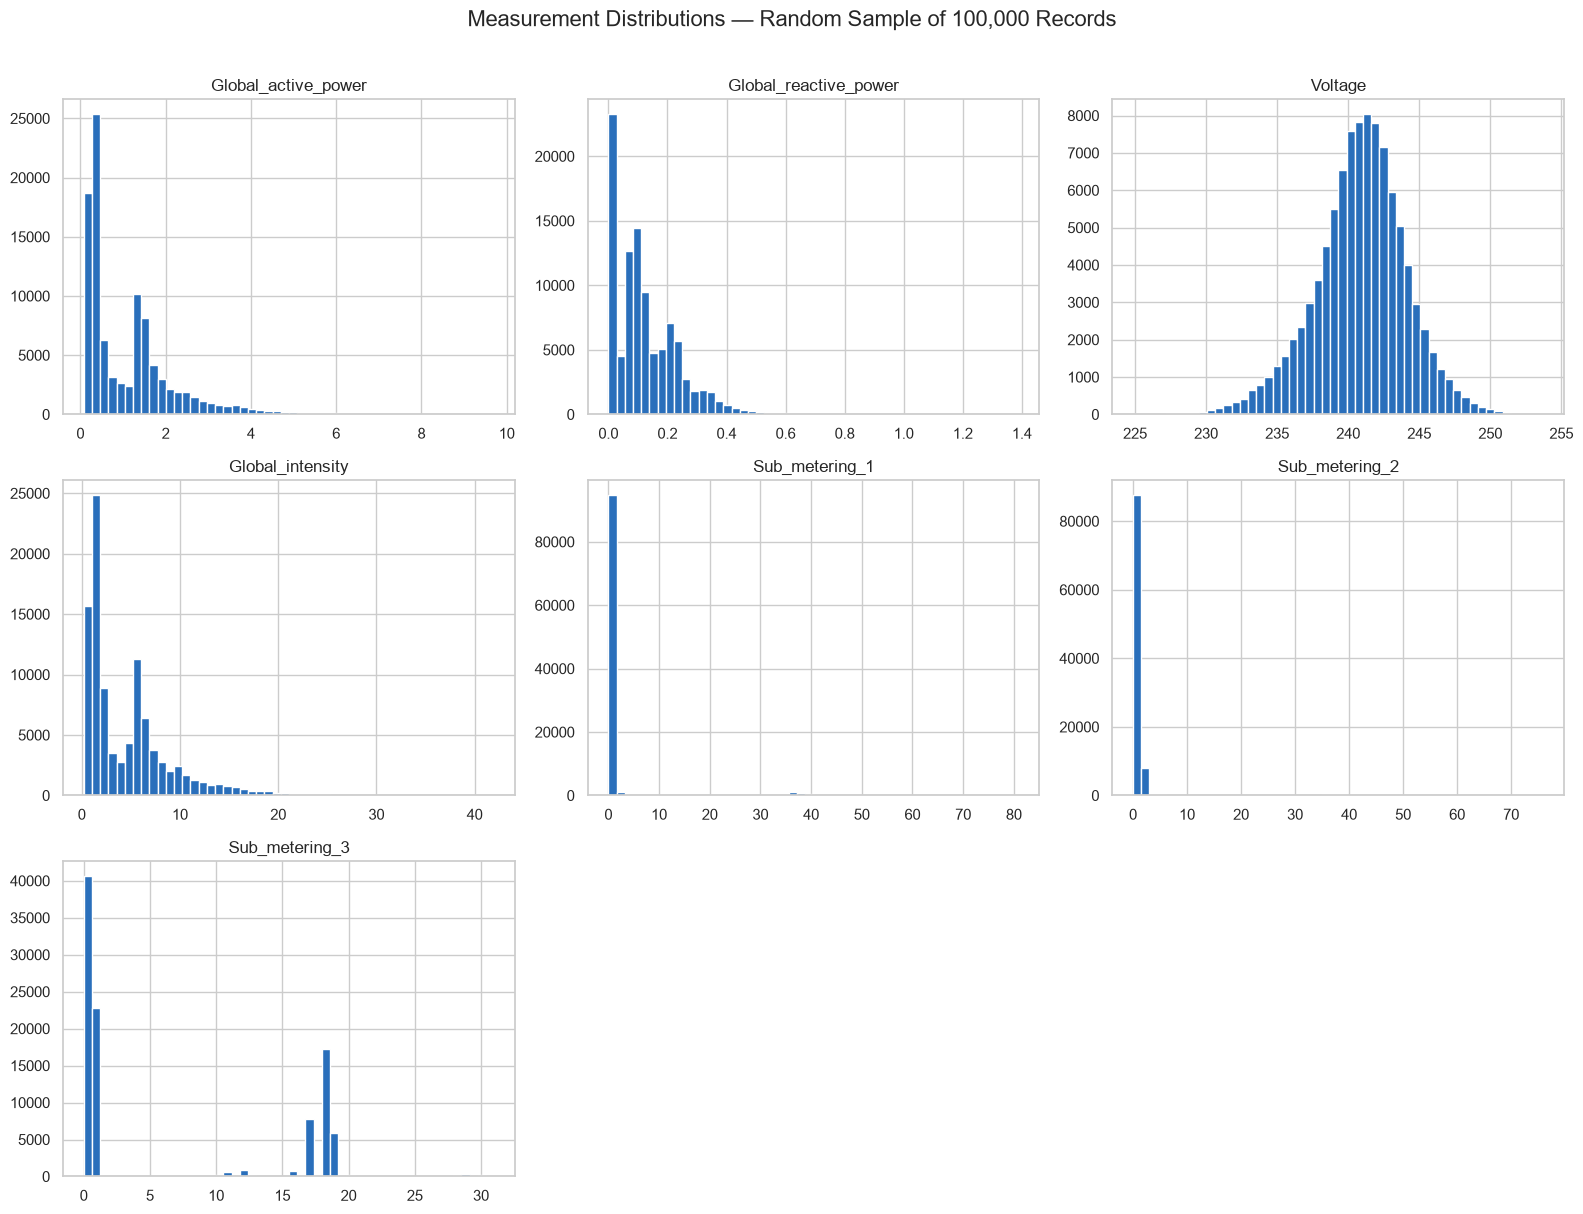

Figure saved to: e:\My_Projects\AIM\capstone\outputs\figures\measurement_distributions.png


In [16]:
plot_sample_size = min(100_000, len(df))

plot_sample = df.sample(
    n=plot_sample_size,
    random_state=RANDOM_STATE
)

axes = plot_sample[numeric_columns].hist(
    bins=50,
    figsize=(16, 12),
    color="#2a6fbb",
    edgecolor="white"
)

plt.suptitle(
    f"Measurement Distributions — Random Sample of "
    f"{plot_sample_size:,} Records",
    fontsize=16,
    y=1.01
)

plt.tight_layout()

distribution_path = FIGURES_DIR / "measurement_distributions.png"
plt.savefig(distribution_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {distribution_path}")


 ## 16. Boxplots for potential outliers



 Separate boxplots are used because the variables have different units and

 numerical scales.

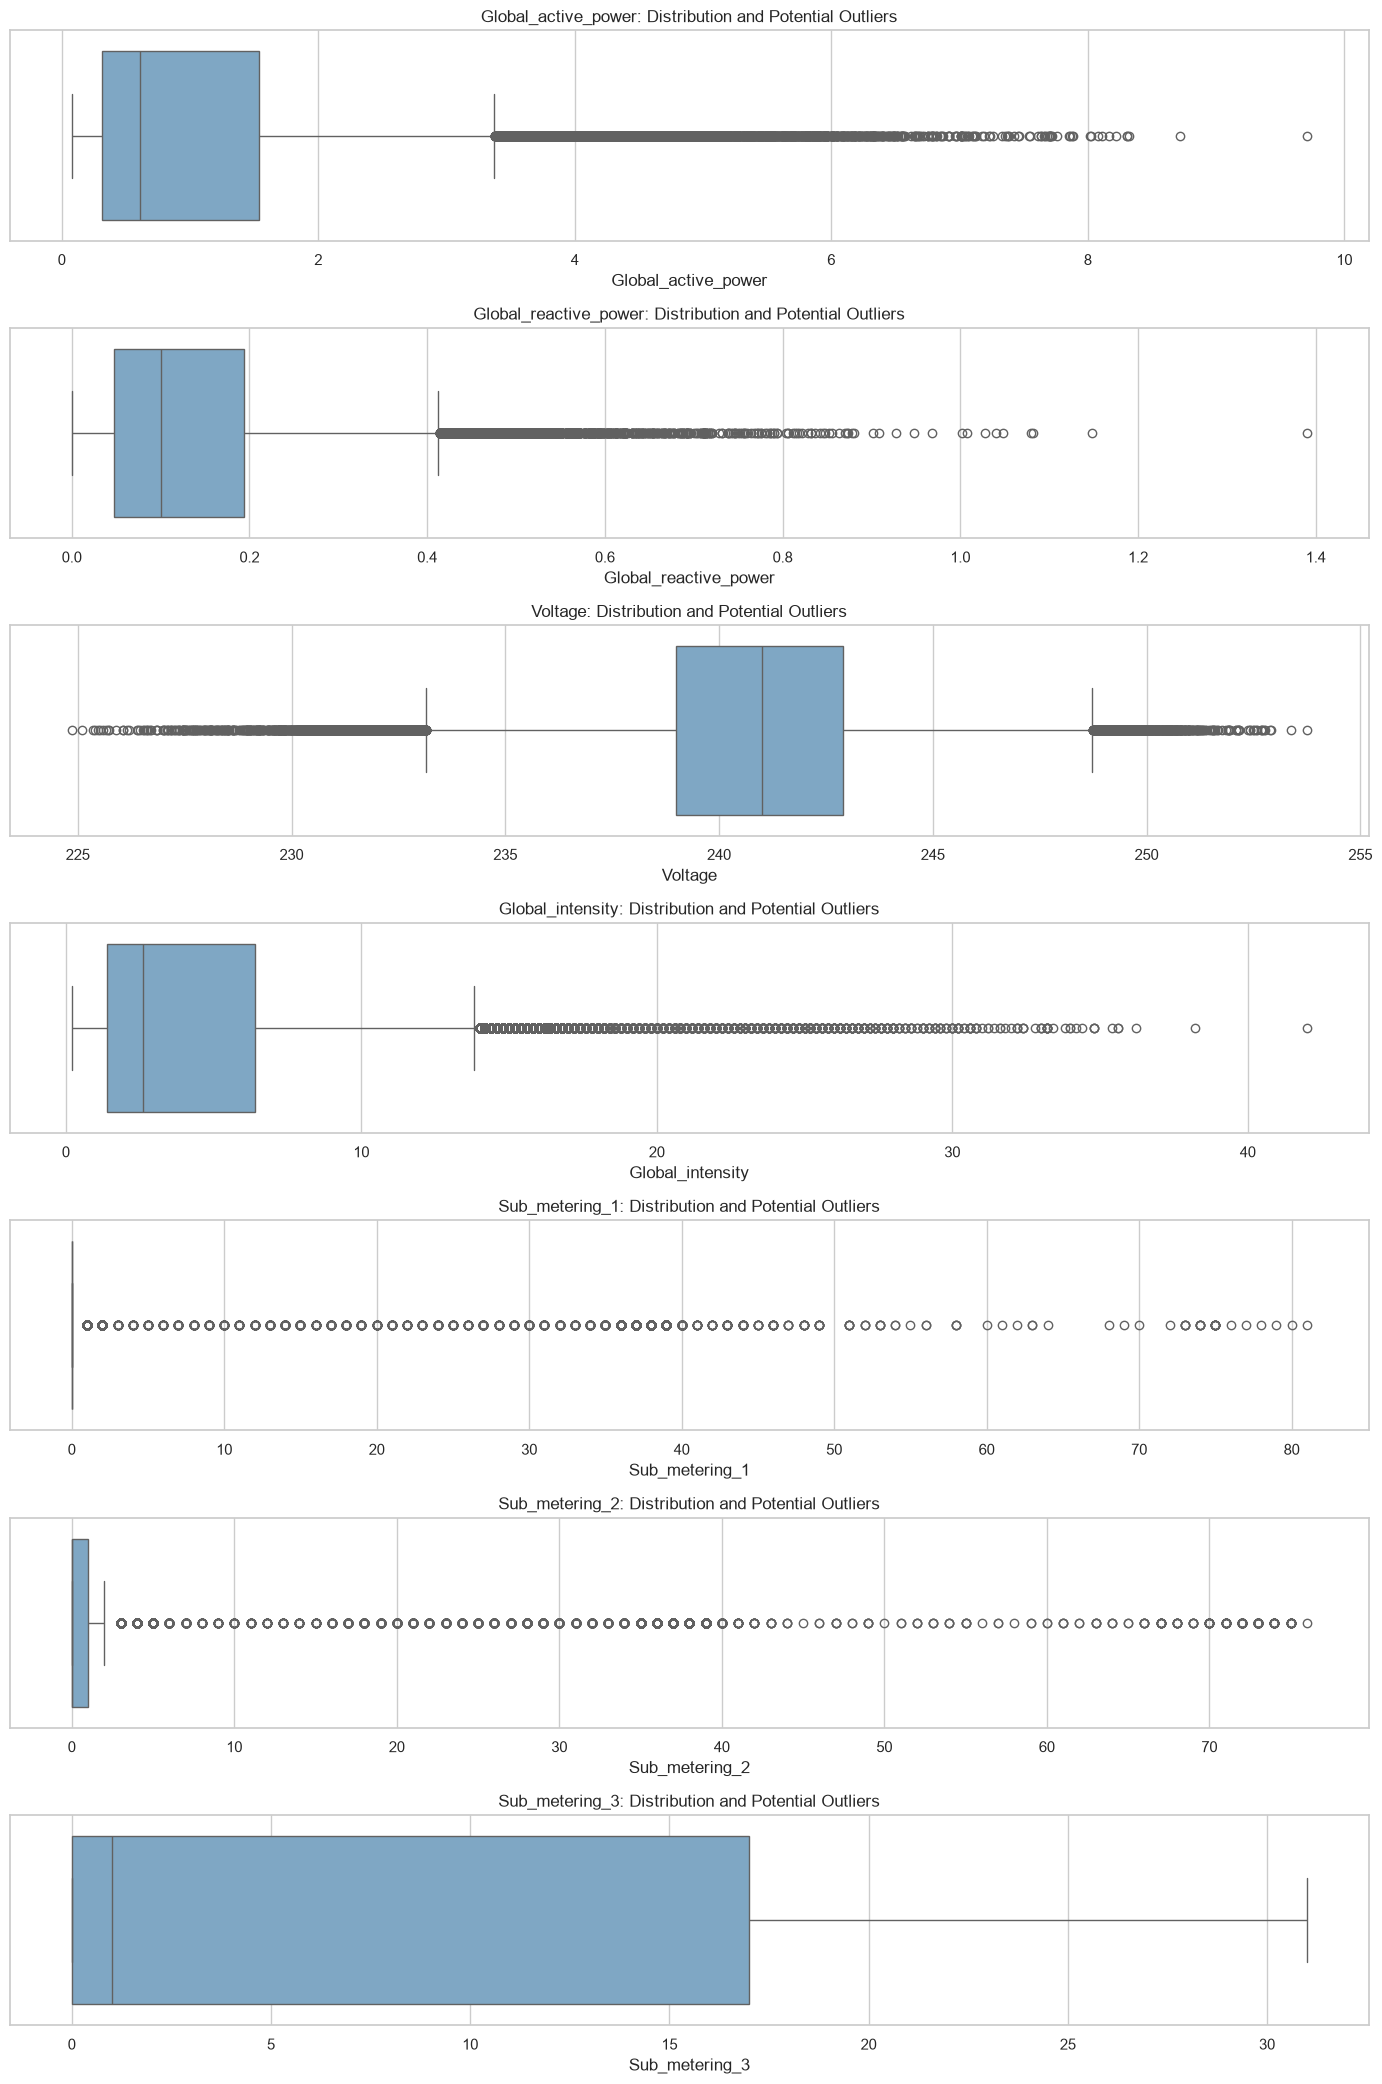

Figure saved to: e:\My_Projects\AIM\capstone\outputs\figures\measurement_boxplots.png


In [17]:
fig, axes = plt.subplots(
    nrows=len(numeric_columns),
    ncols=1,
    figsize=(14, 3 * len(numeric_columns))
)

for ax, column in zip(axes, numeric_columns):
    sns.boxplot(
        x=plot_sample[column],
        ax=ax,
        color="#74a9cf"
    )

    ax.set_title(f"{column}: Distribution and Potential Outliers")
    ax.set_xlabel(column)

plt.tight_layout()

boxplot_path = FIGURES_DIR / "measurement_boxplots.png"
plt.savefig(boxplot_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {boxplot_path}")


 ## 17. Relationships between measurements



 Pearson correlation measures linear relationships between numerical

 variables. High correlation does not prove that one measurement causes

 another.

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Global_active_power,1.0000,0.2470,-0.3998,0.9989,0.4844,0.4346,0.6386
Global_reactive_power,0.2470,1.0000,-0.1122,0.2661,0.1231,0.1392,0.0896
Voltage,-0.3998,-0.1122,1.0000,-0.4114,-0.1960,-0.1674,-0.2682
Global_intensity,0.9989,0.2661,-0.4114,1.0000,0.4893,0.4403,0.6265
Sub_metering_1,0.4844,0.1231,-0.1960,0.4893,1.0000,0.0547,0.1026
Sub_metering_2,0.4346,0.1392,-0.1674,0.4403,0.0547,1.0000,0.0809
Sub_metering_3,0.6386,0.0896,-0.2682,0.6265,0.1026,0.0809,1.0000


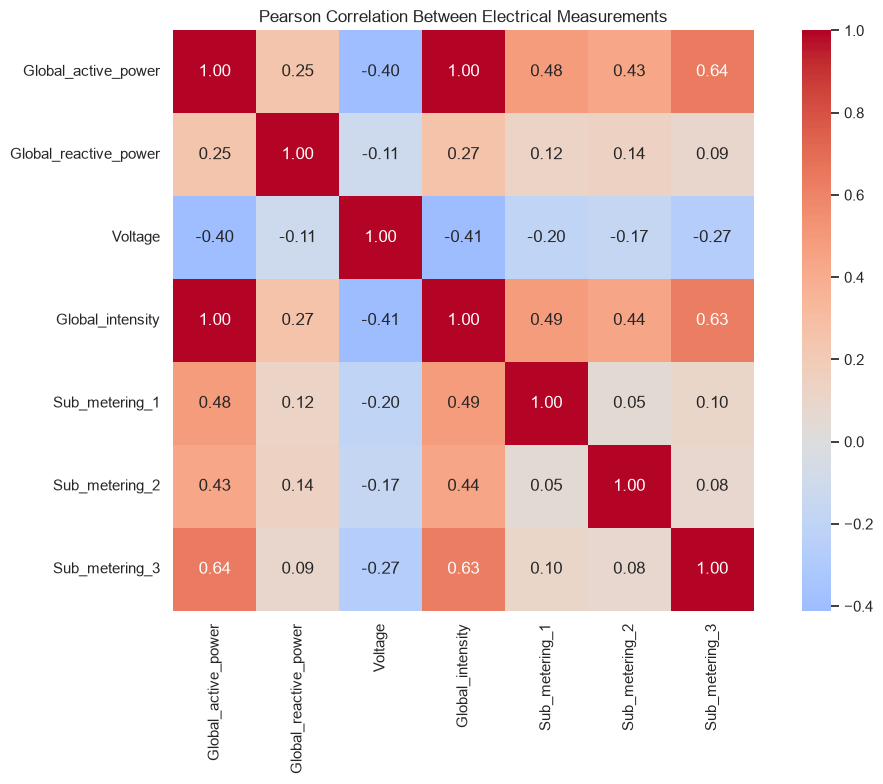

Figure saved to: e:\My_Projects\AIM\capstone\outputs\figures\measurement_correlations.png


In [18]:
correlation_matrix = df[numeric_columns].corr(method="pearson")

display(correlation_matrix)

plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Pearson Correlation Between Electrical Measurements")
plt.tight_layout()

correlation_path = FIGURES_DIR / "measurement_correlations.png"
plt.savefig(correlation_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {correlation_path}")


 ## 18. Consumption trend



 The raw minute-level global active power is resampled into daily energy

 consumption:



 \[

 \text{Daily kWh}

 =

 \frac{\sum \text{minute-level Global Active Power in kW}}{60}

 \]



 Dividing by 60 converts the summed minute-level power readings into

 kilowatt-hours.

,daily_energy_kwh,observed_minutes,coverage_percent
datetime,,,
2006-12-16,20.1529,396,27.5000
2006-12-17,56.5077,1440,100.0000
2006-12-18,36.7304,1440,100.0000
2006-12-19,27.7699,1440,100.0000
2006-12-20,37.0958,1440,100.0000


,daily_energy_kwh,observed_minutes,coverage_percent
count,"1,433.0000","1,442.0000","1,442.0000"
mean,26.0180,"1,421.1373",98.6901
std,10.1137,151.9031,10.5488
min,0.2370,0.0000,0.0000
25%,19.4283,"1,440.0000",100.0000
50%,25.7108,"1,440.0000",100.0000
75%,31.5601,"1,440.0000",100.0000
max,79.5564,"1,440.0000",100.0000


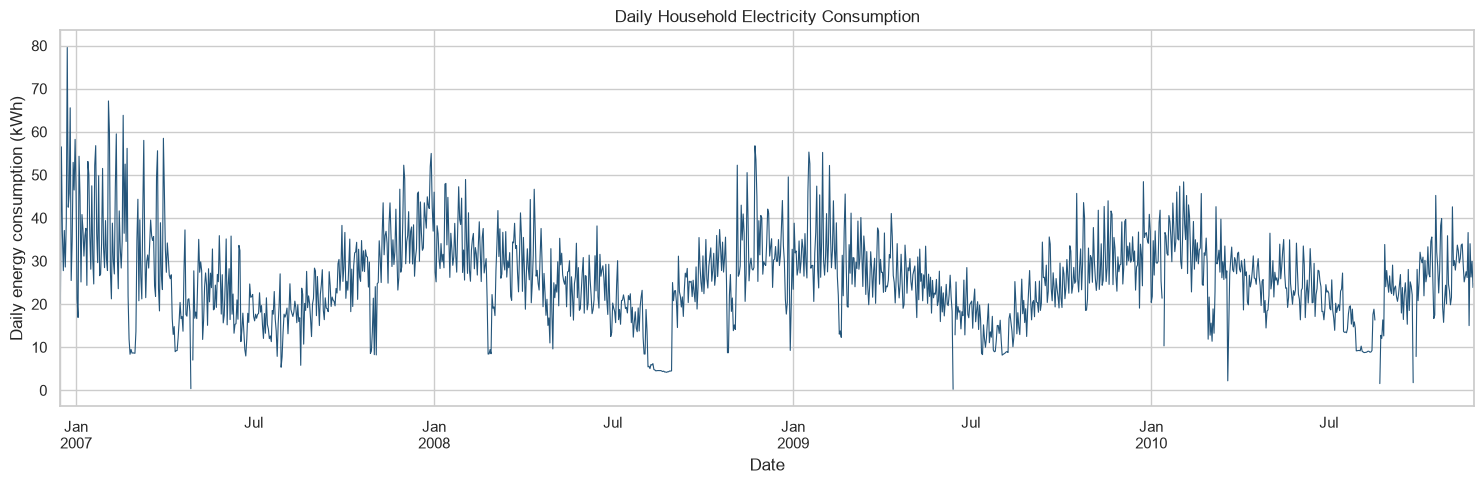

Figure saved to: e:\My_Projects\AIM\capstone\outputs\figures\daily_energy_consumption.png


In [19]:
daily_observed_minutes = df["Global_active_power"].resample("D").count()

daily_consumption = (
    df["Global_active_power"]
      .resample("D")
      .sum(min_count=1)
      .div(60)
      .rename("daily_energy_kwh")
)

daily_overview = pd.concat(
    [
        daily_consumption,
        daily_observed_minutes.rename("observed_minutes"),
    ],
    axis=1
)

daily_overview["coverage_percent"] = (
    daily_overview["observed_minutes"] / 1440 * 100
)

display(daily_overview.head())
display(daily_overview.describe())

fig, ax = plt.subplots(figsize=(15, 5))

daily_overview["daily_energy_kwh"].plot(
    ax=ax,
    color="#24557a",
    linewidth=0.8
)

ax.set_title("Daily Household Electricity Consumption")
ax.set_xlabel("Date")
ax.set_ylabel("Daily energy consumption (kWh)")

plt.tight_layout()

daily_trend_path = FIGURES_DIR / "daily_energy_consumption.png"
plt.savefig(daily_trend_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {daily_trend_path}")


 ## 19. Data dictionary



 The data dictionary combines the official UCI definitions with the observed

 data types and ranges.



 `Observed minimum` and `Observed maximum` are descriptive values from this

 downloaded dataset. They are not universal physical limits.

In [20]:
official_dictionary = [
    {
        "variable": "datetime",
        "description": "Combined observation date and time",
        "role": "Time index",
        "feature_type": "Datetime",
        "unit": "YYYY-MM-DD HH:MM:SS",
        "allowed_values": "Valid timestamps at one-minute intervals",
    },
    {
        "variable": "Global_active_power",
        "description": (
            "Household global minute-averaged active electrical power"
        ),
        "role": "Predictor and basis of target",
        "feature_type": "Continuous numeric",
        "unit": "kilowatt (kW)",
        "allowed_values": "Non-negative real number or missing",
    },
    {
        "variable": "Global_reactive_power",
        "description": (
            "Household global minute-averaged reactive electrical power"
        ),
        "role": "Predictor",
        "feature_type": "Continuous numeric",
        "unit": "kilowatt (kW)",
        "allowed_values": "Non-negative real number or missing",
    },
    {
        "variable": "Voltage",
        "description": "Minute-averaged household voltage",
        "role": "Predictor",
        "feature_type": "Continuous numeric",
        "unit": "volt (V)",
        "allowed_values": "Positive real number or missing",
    },
    {
        "variable": "Global_intensity",
        "description": (
            "Household global minute-averaged current intensity"
        ),
        "role": "Predictor",
        "feature_type": "Continuous numeric",
        "unit": "ampere (A)",
        "allowed_values": "Non-negative real number or missing",
    },
    {
        "variable": "Sub_metering_1",
        "description": (
            "Kitchen energy use, mainly dishwasher, oven, and microwave"
        ),
        "role": "Predictor",
        "feature_type": "Continuous numeric",
        "unit": "watt-hour (Wh)",
        "allowed_values": "Non-negative real number or missing",
    },
    {
        "variable": "Sub_metering_2",
        "description": (
            "Laundry-room energy use, mainly washing machine, tumble dryer, "
            "refrigerator, and lighting"
        ),
        "role": "Predictor",
        "feature_type": "Continuous numeric",
        "unit": "watt-hour (Wh)",
        "allowed_values": "Non-negative real number or missing",
    },
    {
        "variable": "Sub_metering_3",
        "description": (
            "Energy use associated with the electric water heater and "
            "air conditioner"
        ),
        "role": "Predictor",
        "feature_type": "Continuous numeric",
        "unit": "watt-hour (Wh)",
        "allowed_values": "Non-negative real number or missing",
    },
]

data_dictionary = pd.DataFrame(official_dictionary)

data_dictionary["pandas_dtype"] = data_dictionary["variable"].map(
    lambda variable: (
        str(df.index.dtype)
        if variable == "datetime"
        else str(df[variable].dtype)
    )
)

data_dictionary["missing_count"] = data_dictionary["variable"].map(
    lambda variable: (
        int(df.index.isna().sum())
        if variable == "datetime"
        else int(df[variable].isna().sum())
    )
)

data_dictionary["missing_percent"] = data_dictionary["variable"].map(
    lambda variable: (
        float(df.index.isna().mean() * 100)
        if variable == "datetime"
        else float(df[variable].isna().mean() * 100)
    )
)

data_dictionary["observed_minimum"] = data_dictionary["variable"].map(
    lambda variable: (
        df.index.min()
        if variable == "datetime"
        else df[variable].min()
    )
)

data_dictionary["observed_maximum"] = data_dictionary["variable"].map(
    lambda variable: (
        df.index.max()
        if variable == "datetime"
        else df[variable].max()
    )
)

display(data_dictionary)

data_dictionary.to_csv(
    TABLES_DIR / "data_dictionary.csv",
    index=False
)


,variable,description,role,feature_type,unit,allowed_values,pandas_dtype,missing_count,missing_percent,observed_minimum,observed_maximum
0,datetime,Combined observation date and time,Time index,Datetime,YYYY-MM-DD HH:MM:SS,Valid timestamps at one-minute intervals,datetime64[ns],0,0.0000,2006-12-16 17:24:00,2010-11-26 21:02:00
1,Global_active_power,Household global minute-averaged active electr...,Predictor and basis of target,Continuous numeric,kilowatt (kW),Non-negative real number or missing,float64,25979,1.2518,0.0760,11.1220
2,Global_reactive_power,Household global minute-averaged reactive elec...,Predictor,Continuous numeric,kilowatt (kW),Non-negative real number or missing,float64,25979,1.2518,0.0000,1.3900
3,Voltage,Minute-averaged household voltage,Predictor,Continuous numeric,volt (V),Positive real number or missing,float64,25979,1.2518,223.2000,254.1500
4,Global_intensity,Household global minute-averaged current inten...,Predictor,Continuous numeric,ampere (A),Non-negative real number or missing,float64,25979,1.2518,0.2000,48.4000
5,Sub_metering_1,"Kitchen energy use, mainly dishwasher, oven, a...",Predictor,Continuous numeric,watt-hour (Wh),Non-negative real number or missing,float64,25979,1.2518,0.0000,88.0000
6,Sub_metering_2,"Laundry-room energy use, mainly washing machin...",Predictor,Continuous numeric,watt-hour (Wh),Non-negative real number or missing,float64,25979,1.2518,0.0000,80.0000
7,Sub_metering_3,Energy use associated with the electric water ...,Predictor,Continuous numeric,watt-hour (Wh),Non-negative real number or missing,float64,25979,1.2518,0.0000,31.0000


 ## 20. Dataset quality summary

In [21]:
quality_summary = pd.DataFrame(
    {
        "quality_measure": [
            "Number of rows",
            "Number of raw variables",
            "Start timestamp",
            "End timestamp",
            "Rows with missing measurements",
            "Percentage of rows with missing measurements",
            "Rows with duplicated timestamps",
            "Completely duplicated measurement rows",
            "Absent timestamps",
        ],
        "result": [
            f"{len(df):,}",
            f"{len(EXPECTED_COLUMNS)}",
            str(df.index.min()),
            str(df.index.max()),
            f"{rows_with_missing:,}",
            f"{rows_with_missing_percent:.4f}%",
            f"{duplicate_timestamps:,}",
            f"{duplicate_measurement_rows:,}",
            f"{len(missing_timestamps):,}",
        ],
    }
)

display(quality_summary)

quality_summary.to_csv(
    TABLES_DIR / "dataset_quality_summary.csv",
    index=False
)


,quality_measure,result
0,Number of rows,"2,075,259"
1,Number of raw variables,9
2,Start timestamp,2006-12-16 17:24:00
3,End timestamp,2010-11-26 21:02:00
4,Rows with missing measurements,"25,979"
5,Percentage of rows with missing measurements,1.2518%
6,Rows with duplicated timestamps,0
7,Completely duplicated measurement rows,"247,619"
8,Absent timestamps,0


 ## 21. Step 2 conclusions



 ### Dataset suitability



 - The dataset is multivariate time-series data.

 - It contains minute-level household electricity measurements.

 - `Global_active_power` can be converted into daily kWh and used to construct

   the next-day forecasting target.

 - The chronological coverage is long enough to investigate daily, weekly,

   monthly, and seasonal patterns.



 ### Data-quality considerations for Step 3



 - Missing measurement values must be handled without using future information.

 - Timestamp continuity and daily observation coverage must be considered

   before daily aggregation.

 - Duplicate records, if present, require a documented treatment rule.

 - IQR-flagged observations must not be automatically deleted because large

   values may represent genuine consumption spikes.

 - Scaling should be fitted using training data only.

 - Lag and rolling features must use past observations only to avoid leakage.



 ### Generalizability limitation



 The dataset comes from one household in France. Model results will demonstrate

 the feasibility of the forecasting and monitoring method but cannot establish

 expected performance for all Philippine or Meralco households. Validation

 using local multi-household data is recommended for future deployment.

 ## 22. Final Step 2 deliverables

In [22]:
generated_files = sorted(
    [
        path.relative_to(PROJECT_ROOT)
        for path in [
            TABLES_DIR / "missing_value_summary.csv",
            TABLES_DIR / "descriptive_statistics.csv",
            TABLES_DIR / "potential_outlier_summary.csv",
            TABLES_DIR / "data_dictionary.csv",
            TABLES_DIR / "dataset_quality_summary.csv",
            FIGURES_DIR / "measurement_distributions.png",
            FIGURES_DIR / "measurement_boxplots.png",
            FIGURES_DIR / "measurement_correlations.png",
            FIGURES_DIR / "daily_energy_consumption.png",
        ]
        if path.exists()
    ]
)

print("Generated Step 2 artifacts:")

for file_path in generated_files:
    print(f" - {file_path}")

print("\nStep 2 data collection and understanding completed.")

Generated Step 2 artifacts:
 - outputs\figures\daily_energy_consumption.png
 - outputs\figures\measurement_boxplots.png
 - outputs\figures\measurement_correlations.png
 - outputs\figures\measurement_distributions.png
 - outputs\tables\data_dictionary.csv
 - outputs\tables\dataset_quality_summary.csv
 - outputs\tables\descriptive_statistics.csv
 - outputs\tables\missing_value_summary.csv
 - outputs\tables\potential_outlier_summary.csv

Step 2 data collection and understanding completed.
